/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg — Train: 0.993 | Test: 0.972
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Tree (no limit) — Train: 1.000 | Test: 0.944  ← gap = overfitting
Tree (depth=3) — Train: 0.993 | Test: 0.944  ← gap closed


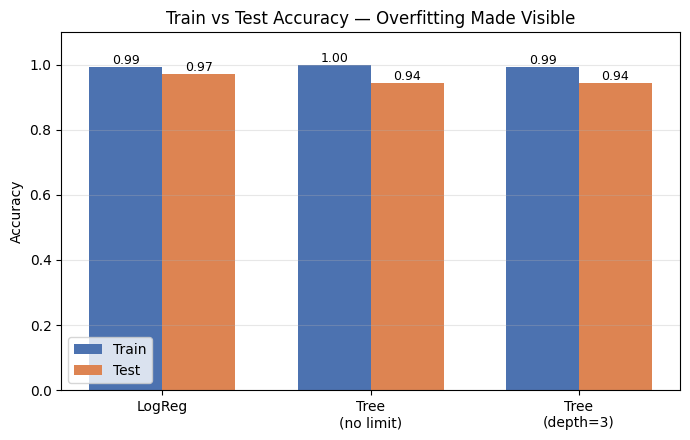

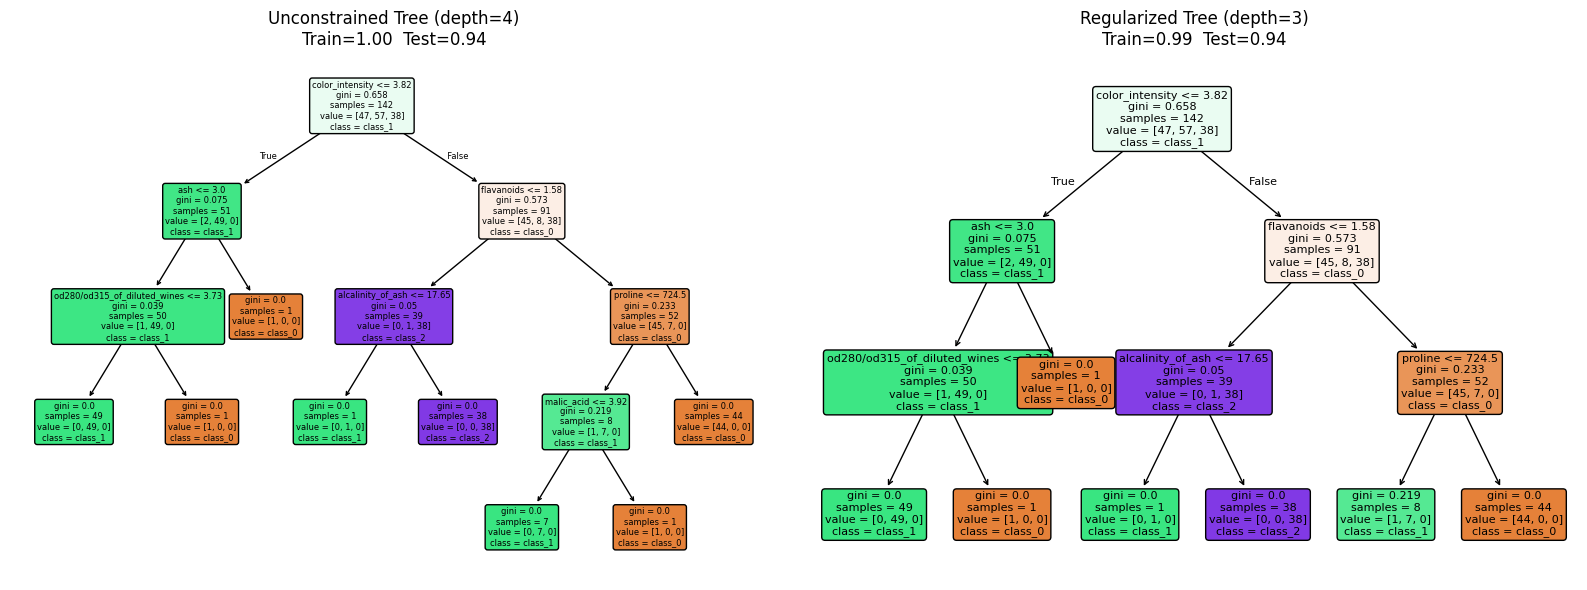

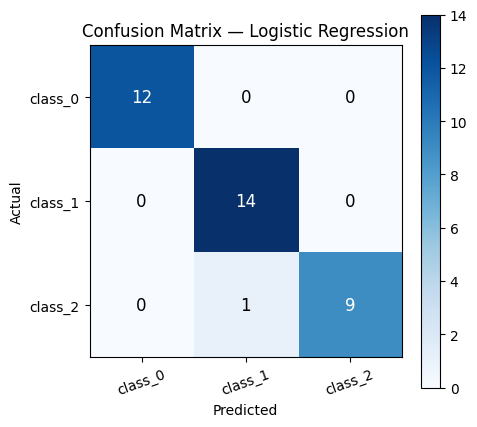

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------
data = load_wine()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------------
# 2. Logistic Regression baseline
# ---------------------------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))

print(f"LogReg — Train: {train_acc:.3f} | Test: {test_acc:.3f}")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

# ---------------------------------------------------------------
# 3. Overfitting demo — unconstrained tree
# ---------------------------------------------------------------
tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(X_train, y_train)
tr = accuracy_score(y_train, tree.predict(X_train))
te = accuracy_score(y_test,  tree.predict(X_test))
print(f"Tree (no limit) — Train: {tr:.3f} | Test: {te:.3f}  ← gap = overfitting")

# ---------------------------------------------------------------
# 4. Regularize — depth 3
# ---------------------------------------------------------------
tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree3.fit(X_train, y_train)
tr3 = accuracy_score(y_train, tree3.predict(X_train))
te3 = accuracy_score(y_test,  tree3.predict(X_test))
print(f"Tree (depth=3) — Train: {tr3:.3f} | Test: {te3:.3f}  ← gap closed")

# ===============================================================
# VISUAL 1: Train vs Test accuracy bar chart
# ===============================================================
models    = ["LogReg", "Tree\n(no limit)", "Tree\n(depth=3)"]
train_accs = [train_acc, tr, tr3]
test_accs  = [test_acc,  te, te3]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
bars1 = ax.bar(x - width/2, train_accs, width, label="Train", color="#4C72B0")
bars2 = ax.bar(x + width/2, test_accs,  width, label="Test",  color="#DD8452")

# annotate values
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy — Overfitting Made Visible")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================================================
# VISUAL 2: Decision tree diagrams (unconstrained vs depth=3)
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_tree(tree, ax=axes[0], filled=True, rounded=True,
          feature_names=data.feature_names, class_names=data.target_names,
          fontsize=6)
axes[0].set_title(f"Unconstrained Tree (depth={tree.get_depth()})\nTrain={tr:.2f}  Test={te:.2f}")

plot_tree(tree3, ax=axes[1], filled=True, rounded=True,
          feature_names=data.feature_names, class_names=data.target_names,
          fontsize=8)
axes[1].set_title(f"Regularized Tree (depth=3)\nTrain={tr3:.2f}  Test={te3:.2f}")

plt.tight_layout()
plt.show()

# ===============================================================
# VISUAL 3: Confusion matrix heatmap — Logistic Regression
# ===============================================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(data.target_names)))
ax.set_yticks(range(len(data.target_names)))
ax.set_xticklabels(data.target_names, rotation=20)
ax.set_yticklabels(data.target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Logistic Regression")

# annotate cell values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=12)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

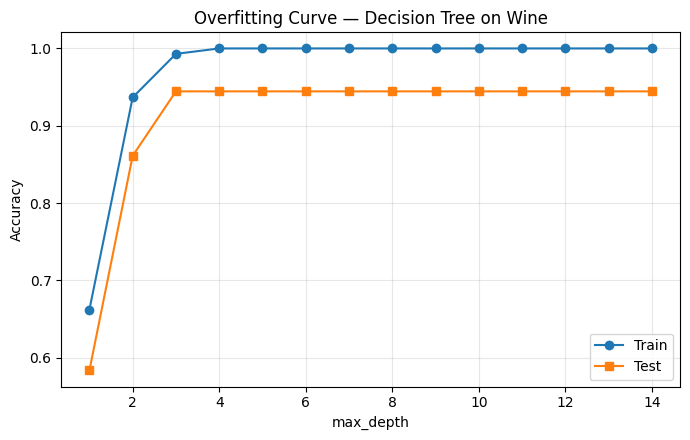

In [2]:
depths = range(1, 15)
train_scores, test_scores = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  t.predict(X_test)))

plt.figure(figsize=(7, 4.5))
plt.plot(depths, train_scores, marker="o", label="Train")
plt.plot(depths, test_scores,  marker="s", label="Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Curve — Decision Tree on Wine")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()